In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [32]:
# --- Load BTC Data ---
btc_df = pd.read_csv("Data/btc_1h_data_2018_to_2025.csv")
btc_df['Open time'] = pd.to_datetime(btc_df['Open time'])
btc_df['Close'] = pd.to_numeric(btc_df['Close'], errors='coerce')

In [33]:
btc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64847 entries, 0 to 64846
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Open time                     64847 non-null  datetime64[ns]
 1   Open                          64847 non-null  float64       
 2   High                          64847 non-null  float64       
 3   Low                           64847 non-null  float64       
 4   Close                         64847 non-null  float64       
 5   Volume                        64847 non-null  float64       
 6   Close time                    64847 non-null  object        
 7   Quote asset volume            64847 non-null  float64       
 8   Number of trades              64847 non-null  int64         
 9   Taker buy base asset volume   64847 non-null  float64       
 10  Taker buy quote asset volume  64847 non-null  float64       
 11  Ignore                      

In [34]:
# Filter BTC data
start = pd.Timestamp("2024-05-01 00:00:00")
end = pd.Timestamp("2024-05-10 23:00:00")
btc_filtered = btc_df[(btc_df['Open time'] >= start) & (btc_df['Open time'] <= end)]

In [35]:
# --- Load Articles Data ---
# Load the JSON file
with open("articles_data_merged.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Convert to DataFrame
articles_df = pd.DataFrame(data)

In [36]:
# Assuming articles_df is already loaded from your JSON
# Step 1: Clean up and combine date + time strings
articles_df['publish_datetime_str'] = articles_df['publish_date'].fillna('') + ' ' + articles_df['publish_time'].fillna('')
articles_df['update_datetime_str'] = articles_df['update_date'].fillna('') + ' ' + articles_df['update_time'].fillna('')

# Step 2: Fix format issues (e.g. "Apr." → "Apr") and remove "at " and " UTC"
articles_df['publish_datetime_str'] = articles_df['publish_datetime_str'].str.replace(r'\bat\b ', '', regex=True).str.replace(' UTC', '').str.replace('.', '')
articles_df['update_datetime_str'] = articles_df['update_datetime_str'].str.replace(r'\bat\b ', '', regex=True).str.replace(' UTC', '').str.replace('.', '')

# Step 3: Parse to datetime
articles_df['publish_datetime'] = pd.to_datetime(articles_df['publish_datetime_str'], format='%b %d, %Y %I:%M %p', errors='coerce')
articles_df['update_datetime'] = pd.to_datetime(articles_df['update_datetime_str'], format='%b %d, %Y %I:%M %p', errors='coerce')

# Optional: Drop the intermediate string columns
articles_df.drop(columns=['publish_datetime_str', 'update_datetime_str'], inplace=True)
articles_df.drop(columns=['publish_date', 'publish_time'], inplace=True)
articles_df.drop(columns=['update_date', 'update_time'], inplace=True)

articles_df['publish_datetime'] = pd.to_datetime(articles_df['publish_datetime'], errors='coerce')
articles_df['impact_score'] = pd.to_numeric(articles_df['impact_score'], errors='coerce')

articles_df = articles_df.sort_values(by='publish_datetime')
articles_df = articles_df.reset_index(drop=True)

In [37]:
# Filter Articles
impact_filtered = articles_df[(articles_df['publish_datetime'] >= start) & 
                               (articles_df['publish_datetime'] <= end)].dropna(subset=['impact_score'])

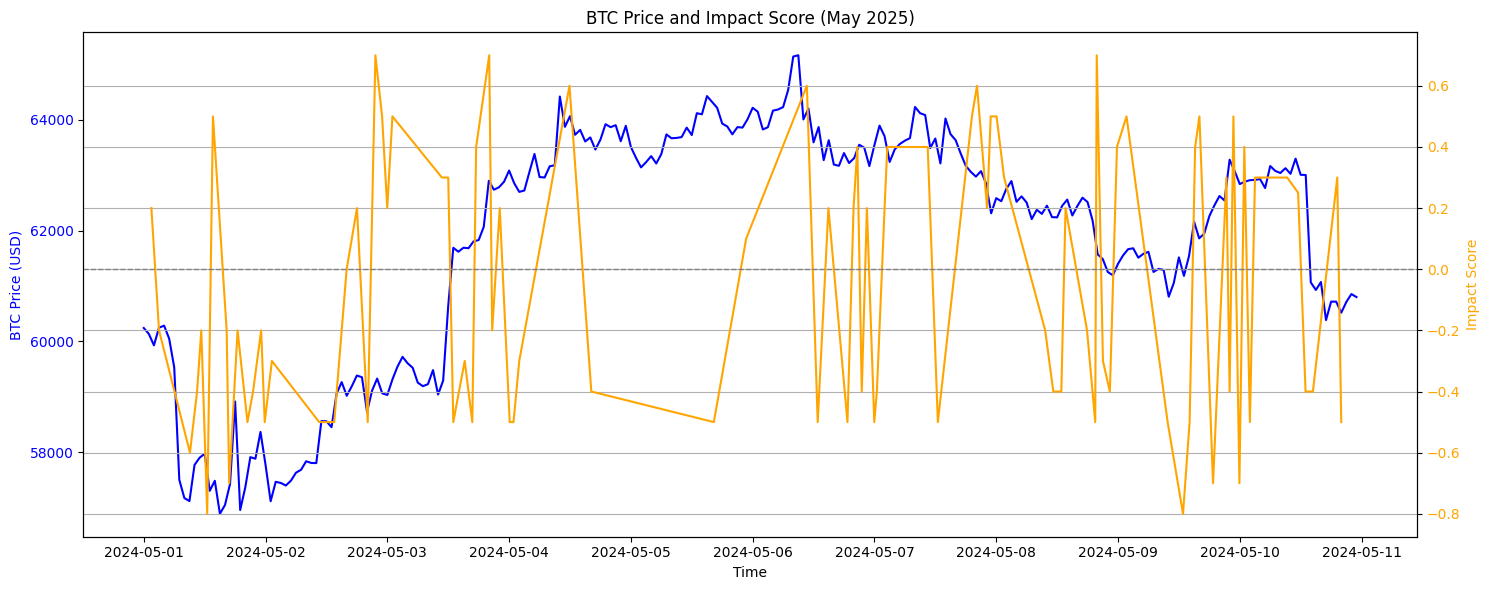

In [38]:
# --- Plot both on one figure with two y-axes ---
fig, ax1 = plt.subplots(figsize=(15, 6))

# BTC Price
ax1.plot(btc_filtered['Open time'], btc_filtered['Close'], color='blue', label='BTC Close Price')
ax1.set_xlabel('Time')
ax1.set_ylabel('BTC Price (USD)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Impact Score on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(impact_filtered['publish_datetime'], impact_filtered['impact_score'], color='orange', label='Impact Score')
ax2.set_ylabel('Impact Score', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)

# Title and Grid
plt.title('BTC Price and Impact Score (May 2025)')
fig.tight_layout()
plt.grid(True)
plt.show()

In [39]:
articles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5427 entries, 0 to 5426
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   url               5427 non-null   object        
 1   label             5427 non-null   object        
 2   impact_score      5427 non-null   float64       
 3   impact_summary    5427 non-null   object        
 4   publish_datetime  5427 non-null   datetime64[ns]
 5   update_datetime   5427 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 254.5+ KB


In [40]:
btc_df

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,0
1,2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,0
2,2018-01-01 02:00:00,13203.00,13418.43,13200.00,13330.18,429.064572,2018-01-01 02:59:59.999,5.710192e+06,4887,192.237935,2.558505e+06,0
3,2018-01-01 03:00:00,13330.26,13611.27,13290.00,13410.03,420.087030,2018-01-01 03:59:59.999,5.657448e+06,4789,137.918407,1.858041e+06,0
4,2018-01-01 04:00:00,13434.98,13623.29,13322.15,13601.01,340.807329,2018-01-01 04:59:59.999,4.588047e+06,4563,172.957635,2.328058e+06,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64842,2025-05-30 20:00:00,104640.49,104846.13,104398.93,104580.00,400.371900,2025-05-30 20:59:59.999,4.185473e+07,76674,187.582680,1.960690e+07,0
64843,2025-05-30 21:00:00,104579.99,104878.05,104553.70,104631.59,288.733160,2025-05-30 21:59:59.999,3.023668e+07,72925,123.262380,1.290719e+07,0
64844,2025-05-30 22:00:00,104631.60,104804.32,103966.32,103966.33,658.818480,2025-05-30 22:59:59.999,6.876925e+07,142757,255.163550,2.664232e+07,0
64845,2025-05-30 23:00:00,103966.32,104260.00,103621.00,103985.48,937.138670,2025-05-30 23:59:59.999,9.742803e+07,260754,408.960200,4.252461e+07,0


In [41]:
articles_df

,url,label,impact_score,impact_summary,publish_datetime,update_datetime
0,https://cryptoslate.com/south-korean-central-b...,cbdcs,-0.6,The announcement of a central bank digital cur...,2023-11-25 02:00:00,2023-11-24 21:51:00
1,https://cryptoslate.com/analyizing-the-impact-...,contributor,-0.3,The article suggests that the adoption of seco...,2023-11-25 04:00:00,2023-11-25 20:05:00
2,https://cryptoslate.com/lightning-network-app-...,regulation,-0.5,The announcement of Wallet of Satoshi's decisi...,2023-11-25 08:00:00,2023-11-24 22:00:00
3,https://cryptoslate.com/bitcoins-resilience-at...,alpha,0.5,The article suggests a strong accumulation tre...,2023-11-25 12:00:00,2023-11-29 16:58:00
4,https://cryptoslate.com/justin-sun-says-htx-an...,hacks,-0.2,The news may have a slightly negative impact o...,2023-11-25 13:48:00,2023-11-27 08:55:00
...,...,...,...,...,...,...
5422,https://cryptoslate.com/former-safemoon-ceo-br...,legal,-0.6,The conviction of SafeMoon's CEO on charges re...,2025-05-23 23:02:00,2025-05-24 01:59:00
5423,https://cryptoslate.com/how-to-best-leverage-l...,contributor,-0.2,"The article discusses the potential of LSDFi, ...",2025-05-24 12:08:00,2025-05-24 12:08:00
5424,https://cryptoslate.com/bad-tokenomics-kill-go...,contributor,-0.4,The article highlights several tokenomics flaw...,2025-05-24 15:00:00,2025-05-24 12:10:00
5425,https://cryptoslate.com/trumps-controversial-m...,politics,-0.6,The news article suggests that the Trump memec...,2025-05-25 00:16:00,2025-05-25 02:34:00


In [42]:
# Ensure datetimes are timezone-aware
btc_df['Open time'] = pd.to_datetime(btc_df['Open time'], utc=True)

# Convert article time from Iran (Asia/Tehran) to UTC
articles_df['publish_datetime'] = pd.to_datetime(articles_df['publish_datetime'])
articles_df['publish_datetime'] = articles_df['publish_datetime'].dt.tz_localize('Asia/Tehran').dt.tz_convert('UTC')

# Define time range in UTC
start_time = pd.Timestamp("2025-04-10 00:00:00", tz="UTC")
end_time = pd.Timestamp("2025-04-20 23:59:59", tz="UTC")

# Filter data
btc_filtered = btc_df[(btc_df['Open time'] >= start_time) & (btc_df['Open time'] <= end_time)]
articles_filtered = articles_df[
    (articles_df['publish_datetime'] >= start_time) &
    (articles_df['publish_datetime'] <= end_time)
]

# Sort articles
articles_filtered = articles_filtered.sort_values('publish_datetime')

# Parameters for weighted sentiment aggregation
window_hours = 72
lambda_decay = 0.05

# Prepare sentiment list
aggregated_sentiment = []

for t in btc_filtered['Open time']:
    window_start = t - pd.Timedelta(hours=window_hours)
    window_df = articles_filtered[
        (articles_df['publish_datetime'] > window_start) &
        (articles_df['publish_datetime'] <= t)
    ]

    if not window_df.empty:
        delta_hours = (t - window_df['publish_datetime']).dt.total_seconds() / 3600.0
        weights = np.exp(-lambda_decay * delta_hours)
        weighted_avg = np.average(window_df['impact_score'], weights=weights)
    else:
        weighted_avg = np.nan

    aggregated_sentiment.append(weighted_avg)

# Add sentiment to BTC data
btc_filtered['aggregated_sentiment'] = aggregated_sentiment


/tmp/ipykernel_5692/2859350896.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  window_df = articles_filtered[
/tmp/ipykernel_5692/2859350896.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  window_df = articles_filtered[
/tmp/ipykernel_5692/2859350896.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  window_df = articles_filtered[
/tmp/ipykernel_5692/2859350896.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  window_df = articles_filtered[
/tmp/ipykernel_5692/2859350896.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  window_df = articles_filtered[
/tmp/ipykernel_5692/2859350896.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  window_df = articles_filtered[
/tmp/ipykernel_5692/2859350896.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  wi

In [43]:
btc_filtered

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore,aggregated_sentiment
63622,2025-04-10 00:00:00+00:00,82615.22,82753.21,82056.19,82352.85,1636.34707,2025-04-10 00:59:59.999,1.348058e+08,160629,934.78245,7.700134e+07,0,NaN
63623,2025-04-10 01:00:00+00:00,82352.85,82600.00,82224.90,82249.29,1471.70076,2025-04-10 01:59:59.999,1.213236e+08,145970,938.68432,7.738649e+07,0,NaN
63624,2025-04-10 02:00:00+00:00,82249.29,82565.19,82195.77,82200.00,871.82875,2025-04-10 02:59:59.999,7.180516e+07,98411,521.97978,4.298397e+07,0,NaN
63625,2025-04-10 03:00:00+00:00,82201.24,82224.45,81472.84,81775.20,1478.04577,2025-04-10 03:59:59.999,1.208859e+08,134491,607.01706,4.961422e+07,0,NaN
63626,2025-04-10 04:00:00+00:00,81775.20,82088.75,81640.74,82019.26,563.81007,2025-04-10 04:59:59.999,4.614710e+07,80848,302.81141,2.479139e+07,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63881,2025-04-20 19:00:00+00:00,84577.79,84664.09,84521.73,84651.61,139.48309,2025-04-20 19:59:59.999,1.179768e+07,22119,59.50471,5.033167e+06,0,-0.087823
63882,2025-04-20 20:00:00+00:00,84651.61,85250.00,84616.73,85127.58,693.63733,2025-04-20 20:59:59.999,5.898724e+07,84993,375.28803,3.190990e+07,0,-0.087242
63883,2025-04-20 21:00:00+00:00,85127.58,85244.02,84913.04,85009.27,276.81879,2025-04-20 21:59:59.999,2.354196e+07,42875,105.02153,8.932485e+06,0,0.049633
63884,2025-04-20 22:00:00+00:00,85009.27,85031.19,84669.73,84835.28,272.57238,2025-04-20 22:59:59.999,2.311383e+07,46987,100.35702,8.511670e+06,0,0.049633


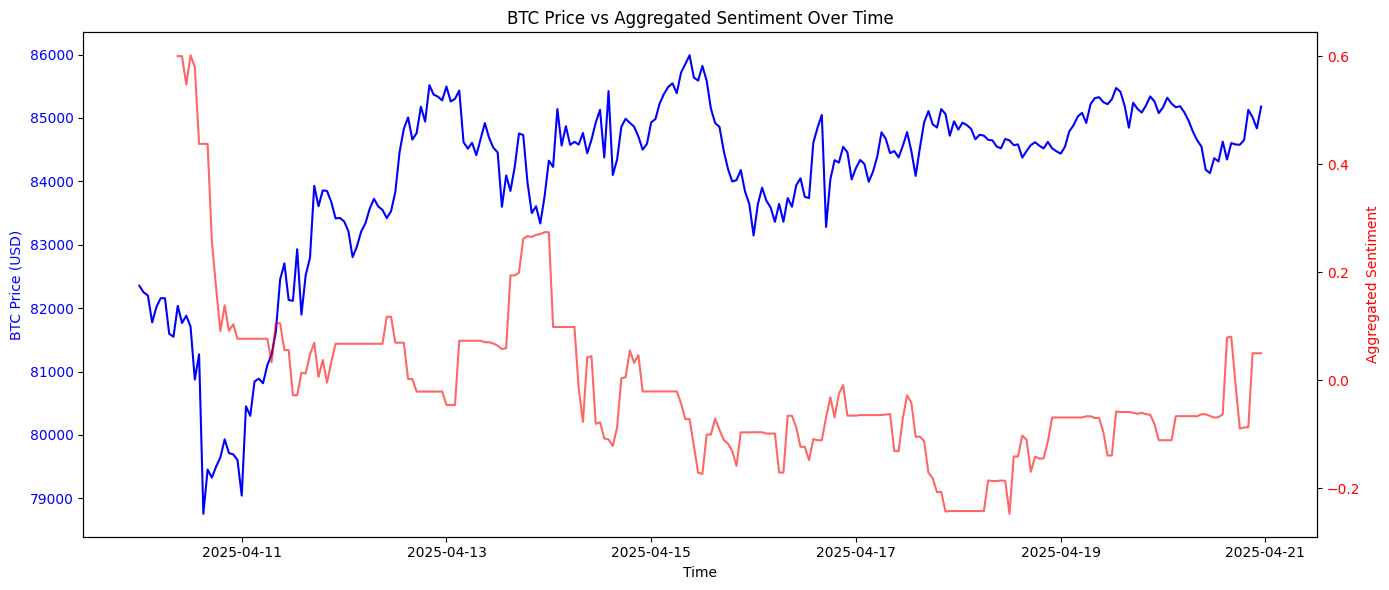

In [44]:
import matplotlib.pyplot as plt

# Plot BTC price and sentiment
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot BTC price on left y-axis
ax1.plot(btc_filtered['Open time'], btc_filtered['Close'], color='blue', label='BTC Price')
ax1.set_xlabel('Time')
ax1.set_ylabel('BTC Price (USD)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis for sentiment
ax2 = ax1.twinx()
ax2.plot(btc_filtered['Open time'], btc_filtered['aggregated_sentiment'], color='red', label='Sentiment', alpha=0.6)
ax2.set_ylabel('Aggregated Sentiment', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and legend
plt.title('BTC Price vs Aggregated Sentiment Over Time')
fig.tight_layout()
plt.show()
